# Automotive Demand Trends & Customer Purchase Behavior Analysis

**Business Context**:

Austo, a UK-based automobile company, is expanding into the US market and requires insights into customer preferences, vehicle demand patterns, and key factors influencing purchase behavior. A market dataset has been provided to enable data-driven understanding of buyer segments and market dynamics.

**Objectives**:

- Analyze customer and vehicle data to identify overall demand trends across car categories
- Develop buyer profiles and segmentation based on purchasing behavior and preferences
- Examine key factors influencing vehicle selection and purchase decisions
- Provide actionable insights for market entry, product positioning, demand-driven and production planning


In [1]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

## Sanity Checks

#### Loading and displaying the first and last few rows of the dataset

In [2]:
df = pd.read_csv("C:/Users/HP PC/Downloads/austo_automobile.csv")
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback


In [3]:
df.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,28,Male,Salaried,Married,Post Graduate,2,Yes,No,No,72000,0,72000,33000,Hatchback
1577,23,Male,Salaried,Single,Graduate,2,Yes,Yes,No,37000,0,37000,33000,Hatchback
1578,23,Male,Business,Married,Graduate,4,Yes,Yes,Yes,38000,28000,66000,33000,Hatchback
1579,25,Male,Business,Married,Post Graduate,3,Yes,Yes,Yes,58000,40000,98000,33000,Hatchback
1580,28,Male,Salaried,Married,Graduate,4,No,Yes,Yes,54000,40000,94000,33000,Hatchback


- The `Age` column contains the age of the customer
- The `Gender` column contains the customer's sex
- The `Profession` column contains the type of employment of the customer
- The `Marital_status` column contains the marital status of the customer
- The `Education` column contains the highest educational qualification of the customer
- The `Make` column contains the type of car purchased or owned by the customer
- The remaining columns contain other important attributes of the data
- At a glance, everything appears to be okay with the dataset 

#### Checking the shape of the datatset

In [4]:
df.shape

(1581, 14)

There are 1581 rows and 14 columns in the dataset

#### Checking the datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.0+ KB


- There are 6 numerical and 8 categorical features in the dataset
- All features have been saved with the appropriate datatypes, either integer or object
- There does not appear to be missing values in the dataset

#### Checking the statistical summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.00000,32.21126,9.12548,22.00000,25.00000,29.00000,38.00000,60.00000
No_of_Dependents,1581.00000,2.45794,0.94348,0.00000,2.00000,2.00000,3.00000,4.00000
Salary,1581.00000,59732.44782,14278.64266,30000.00000,51000.00000,59000.00000,71000.00000,90000.00000
Partner_salary,1581.00000,19720.43011,19480.21440,0.00000,0.00000,25000.00000,38000.00000,80000.00000
Total_salary,1581.00000,79452.87793,24855.93604,30000.00000,61000.00000,78000.00000,96000.00000,158000.00000
Price,1581.00000,35597.72296,13633.63655,18000.00000,25000.00000,31000.00000,47000.00000,70000.00000


- 50% of customers are less than 30 years of age
- 75% of customers have at least 2 dependents or more
- Asides the variable `Partner_salary` which has its median greater than the mean, all other variables have their means slightly greater than their median meaning they will be positively skewed
- There is significant difference between the 75th percentile and maximum values of all variables except `Age`, indicating there are likely outliers present to the right in those variables
- The average salary of customers is about 60000
- The minimum price of cars purchased by customers is 18000 while the maximum is 70000

#### Checking for missing values

In [7]:
df.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

As observed earlier from the dataset info, there are no missing values present

#### Checking for duplicates in the dataset

In [8]:
df.duplicated().sum()

0

There are no duplicates in the dataset

#### Let's check out the categorical levels in the dataset

In [9]:
df.columns

Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='object')

In [10]:
cat_cols = ['Gender', 'Profession', 'Marital_status', 'Education','Personal_loan', 'House_loan', 'Partner_working', 'Make']

for item in cat_cols:
    print(item, '\n')
    print(df[item].value_counts())
    print(df[item].value_counts(normalize=True))
    print('-' * 45)

Gender 

Male      1252
Female     329
Name: Gender, dtype: int64
Male     0.79190
Female   0.20810
Name: Gender, dtype: float64
---------------------------------------------
Profession 

Salaried    896
Business    685
Name: Profession, dtype: int64
Salaried   0.56673
Business   0.43327
Name: Profession, dtype: float64
---------------------------------------------
Marital_status 

Married    1443
Single      138
Name: Marital_status, dtype: int64
Married   0.91271
Single    0.08729
Name: Marital_status, dtype: float64
---------------------------------------------
Education 

Post Graduate    985
Graduate         596
Name: Education, dtype: int64
Post Graduate   0.62302
Graduate        0.37698
Name: Education, dtype: float64
---------------------------------------------
Personal_loan 

Yes    792
No     789
Name: Personal_loan, dtype: int64
Yes   0.50095
No    0.49905
Name: Personal_loan, dtype: float64
---------------------------------------------
House_loan 

No     1054
Yes     527


- About 80% of customers are male while 20% are female
- Majority of the customers (1443) are married  while 134 are single
- 896 customers are salary earners while 685 are business owners
- At 985 to 596, there are more customers educated to postgraduate level compared to graduate level
- There are almost equal numbers of customers who either availed themselves of personal loans (50.1%) or did not (49.9%)
- 527 customers took house loans, and 2 times than number (1054) did not
- About 55% of customers have partners who work while about 45% have partner who do not
- Customers purchased 3 different car makes. Hatchback was purchased the most by 884 customers, followed by Sedan by 460, and then SUV by 237 customers

## Univariate Analysis

#### Observations on Age

In [11]:
df.head(2)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback


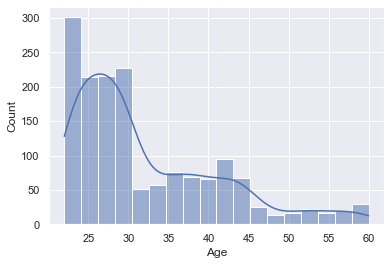

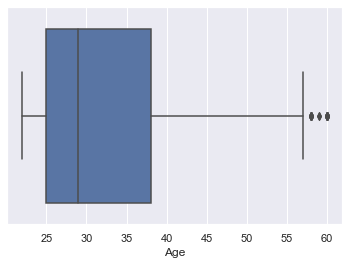

In [12]:
sns.histplot(df, x='Age', kde=True);
plt.show()
sns.boxplot(data=df, x='Age');
plt.show()

- The distribution of Age is right skewed
- 25% of customers are aged above 38
- There are few outliers after age 57. Let's investigate further

In [13]:
df.loc[df['Age']>57]['Age'].value_counts()

60    15
58    12
59     2
Name: Age, dtype: int64

In [14]:
df.loc[df['Age']>57]['Age'].value_counts().sum()

29

Ages between 58 and 60 are seen as outliers, and there are 29 customers whose ages fall within this bracket

#### Observations on Number of Dependents

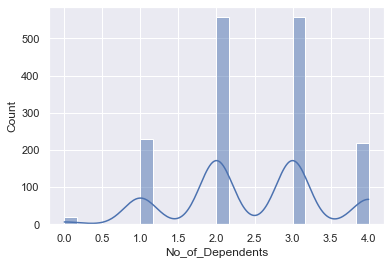

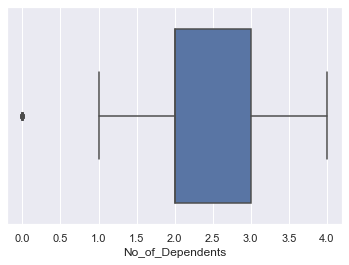

In [15]:
sns.histplot(df, x='No_of_Dependents', kde= True);
plt.show()
sns.boxplot(data=df, x='No_of_Dependents');
plt.show()

- As seen earlier from the statistical summary, majority of customers have dependents
- The median number of dependents is equal to the 1st quartile at 2
- The distribution of this column is positively skewed
- There is a concentration of outliers at 0, and those are the *no dependent* group. Let's see how many they are 

In [16]:
len(df.loc[df['No_of_Dependents']==0])

20

There are 20 customers with no dependents

#### Observations on Salary

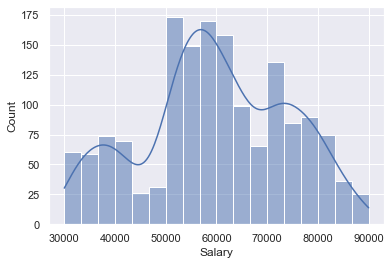

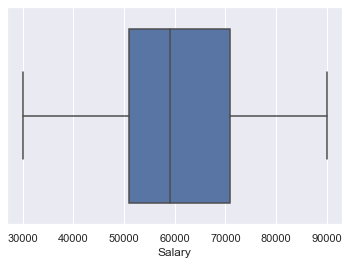

In [17]:
sns.histplot(df, x='Salary', kde= True);
plt.show()
sns.boxplot(data=df, x='Salary');
plt.show()

- Contrary to our initial suspicion, there are actually no outliers in the Salary column
- The column is almost normally distributed; it is slightly right-skewed
- The median salary is 59000

In [18]:
len(df.loc[df['Salary']>59000])

769

#### Observations on Partner's Salary

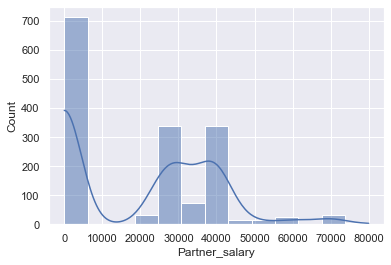

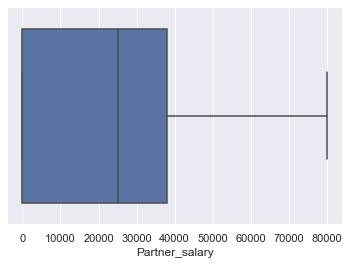

In [19]:
sns.histplot(df, x='Partner_salary', kde= True);
plt.show()
sns.boxplot(data=df, x='Partner_salary');
plt.show()

- The minimum value of the Partner salary column is equal to the 1st quartile at 0, which also means that 25% of customers either do not have partners or have partners who do not earn salary
- The distribution is skewed to the left
- There are no outliers in the column
- There are customers whose partners earn as much as 80000

In [20]:
df.loc[df['Partner_salary']==0].shape[0]

713

In [21]:
df.loc[(df['Marital_status']=='Married') & (df['Partner_salary']==0)].shape[0]

575

In [22]:
df.loc[df['Marital_status']=='Single'].shape[0]

138

There are 713 customers who either do not have partners (138) or have partners who do not earn salary (575)

#### Observations on Total Salary

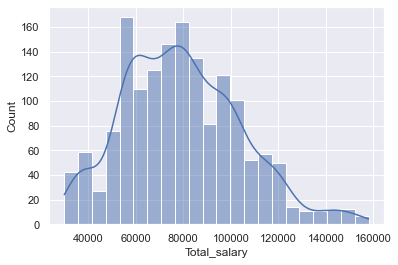

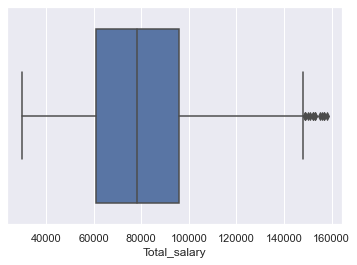

In [23]:
sns.histplot(df, x='Total_salary', kde= True);
plt.show()
sns.boxplot(data=df, x='Total_salary');
plt.show()

- The distribution of Total salary is positively-skewed
- The majority of values are between the 58000 and 110000 salary bracket
- The 75% of customers have total salaries above 61000
- Values above 148000 are considered outliers

#### Observations on Price

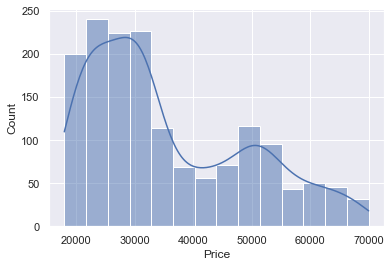

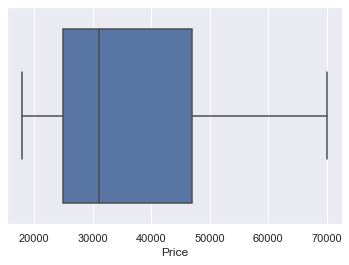

In [24]:
sns.histplot(df, x='Price', kde= True);
plt.show()
sns.boxplot(data=df, x='Price');
plt.show()

- The distribution of Price is right-skewed
- 50% of car prices are above 31000

#### Moving to the categorical features now 

In [25]:
df.head(2)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback


#### Observations on Gender

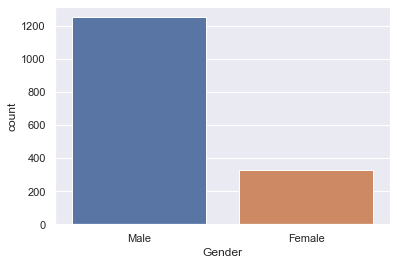

In [26]:
sns.countplot(data=df, x = 'Gender');

There are more male customers than female ones; they are about 4 times the number of female customers

In [27]:
df.loc[df['Gender']=='Female'].shape[0]

329

In [28]:
df.loc[(df['Gender']=='Female') & (df['Marital_status']=='Single')].shape[0]

22

Of 329 total female customers, only 22 are single

#### Observations on Profession

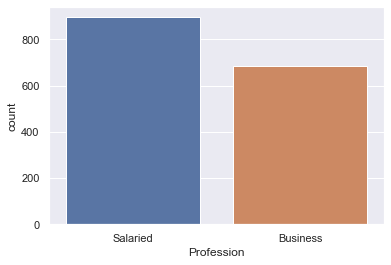

In [29]:
sns.countplot(data=df, x = 'Profession');

Salaried customers surpass customers who own business. It will be interesting to see how this impacts the choice of car make purchased

#### Observations on Marital Status

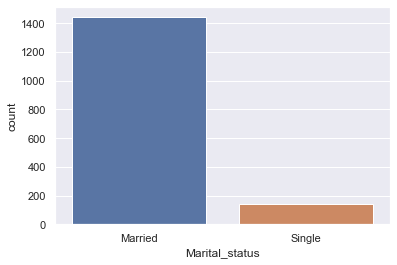

In [30]:
sns.countplot(data=df, x = 'Marital_status');

There are far more married customers compared to single ones

#### Observations on Education

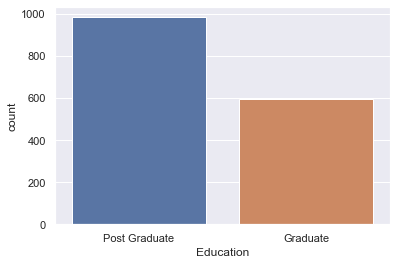

In [31]:
sns.countplot(data=df, x = 'Education');

Graduate-level customers are lesser than post graduate-level customers

#### Observations on Personal Loan

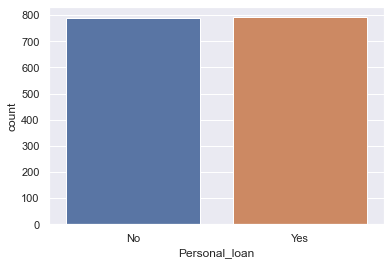

In [32]:
sns.countplot(data=df, x = 'Personal_loan');

There is practically equal number of customers who took personal loans and those who did not

In [33]:
df['Personal_loan'].value_counts()

Yes    792
No     789
Name: Personal_loan, dtype: int64

792 customers took the loan while 789 did not

#### Observations on House Loan

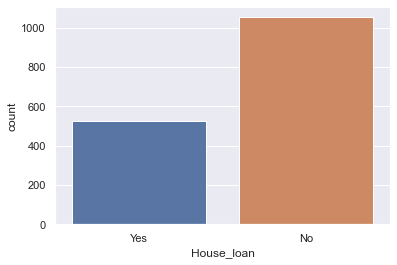

In [34]:
sns.countplot(data=df, x = 'House_loan');

Less customers availed themselves of house loans while more of them did not

#### Observations on Partner Working

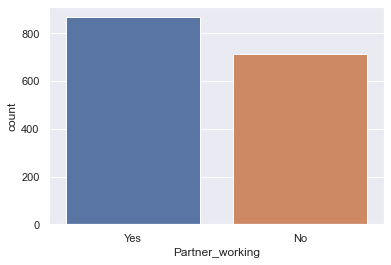

In [35]:
sns.countplot(data=df, x = 'Partner_working');

Over those whose partners do not work, there are more customers whose partners do

#### Observations on Car Make

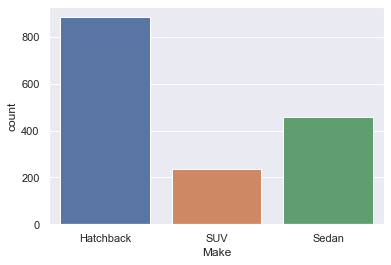

In [36]:
sns.countplot(data=df, x = 'Make');

- Hatchback cars were purchased the most by customers, followed by Sedans
- SUVs were the least purchased

## Bivariate Analysis

#### Correlation by Heatmap

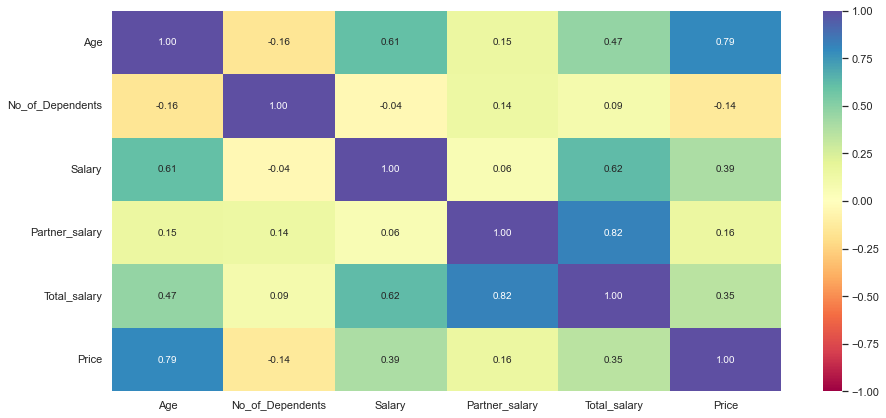

In [37]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral');
plt.show()

- Asides `No_of_Dependents` with which there is a negative correlation, `Age` has a significant postive correlation with all other variables. Given that all customers are educated and working class, the postive correlation could be attributed to rise in earning and purchasing power as customers age and progress at their various jobs
- The correlation between `Price` and other variables is similar to that between `Age` and the others.
- `Total_salary` has a strong positive correlation with `Partner_salary` and `Salary`, this is not surprising as the latter two were added up to give the former
- `No_of_Dependents` has either a negative or a weak positive correlation with other variables

In [ ]:
df.columns #trying to extract required columns for pairplot

#### Scatterplots

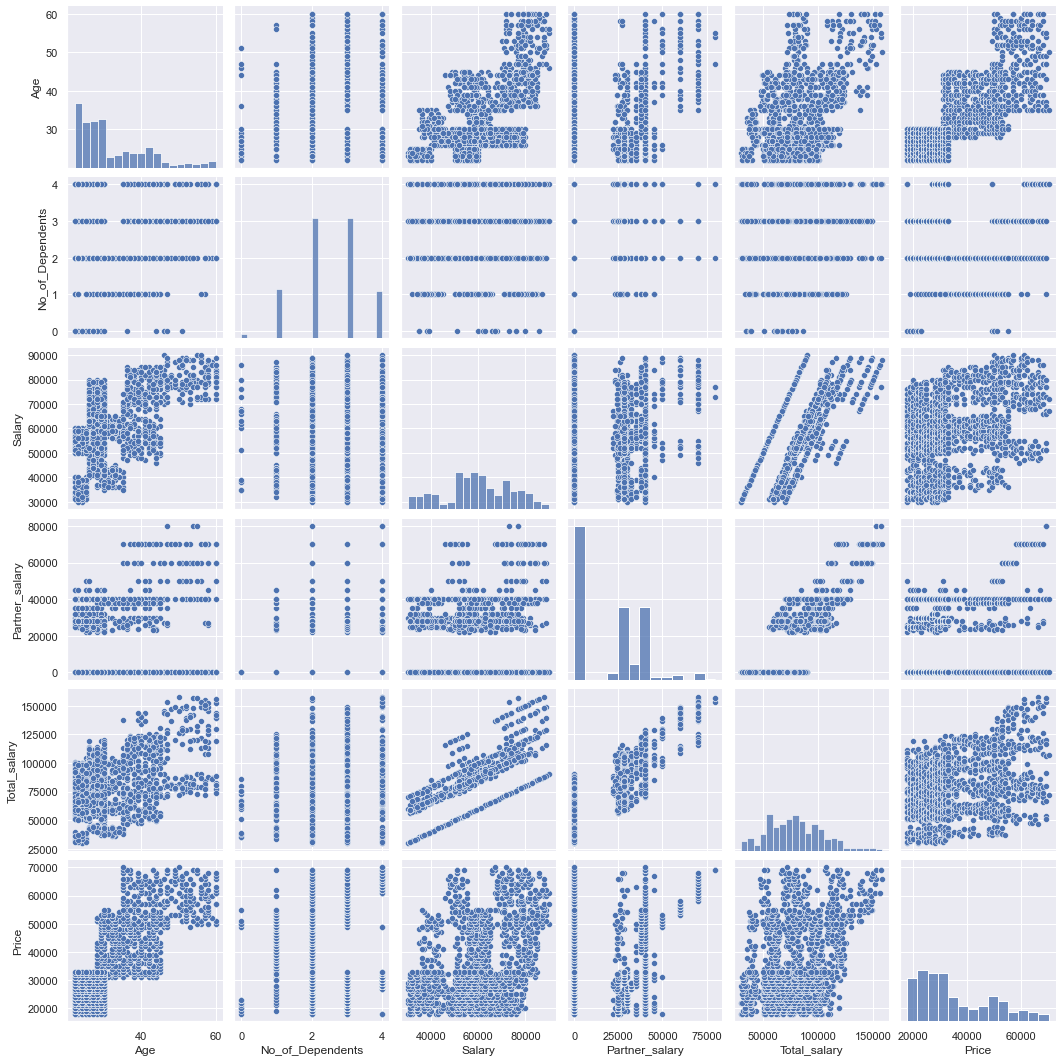

In [39]:
sns.pairplot(df[['Age','No_of_Dependents','Salary','Partner_salary', 'Total_salary', 'Price']]);

The scatter plots of the numerical variables give similar insights as the heatmap

In [40]:
df.head(2)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback


#### Relationship between Age and Make

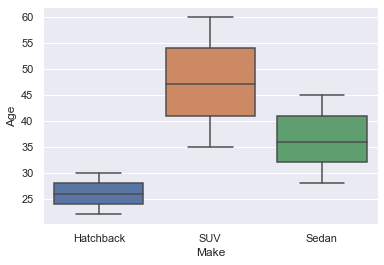

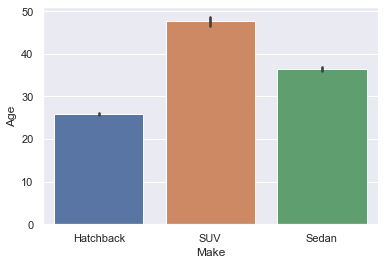

In [41]:
sns.boxplot(data=df, x='Make', y='Age');
plt.show()
sns.barplot(data=df, x='Make', y='Age');
plt.show()

In [42]:
print(df.groupby(['Make'])['Age'].mean())
print(df.groupby(['Make'])['Age'].min())
print(df.groupby(['Make'])['Age'].max())

Make
Hatchback   25.87443
SUV         47.60338
Sedan       36.45870
Name: Age, dtype: float64
Make
Hatchback    22
SUV          35
Sedan        28
Name: Age, dtype: int64
Make
Hatchback    30
SUV          60
Sedan        45
Name: Age, dtype: int64


- **Hatchback**: Customers who purchase this type of car have the an average age of 25. Their ages are between 22 and 30
- **SUV**: Customers who purchase this type of car have the an average age of 47. Their ages are between 35 and 60
- **Sedan**: Customers who purchase this type of car have the an average age of 36. Their ages are between 28 and 45

Let's see the percentage of customers who bought each car make

In [43]:
df.loc[(df['Make']=='Hatchback') & (df['Age']<=30)].shape[0]/df.shape[0]*100

55.91397849462365

In [44]:
df.loc[(df['Make']=='Sedan') & (df['Age']>=28) & (df['Age']<=45)].shape[0]/df.shape[0]*100

29.095509171410498

In [45]:
df.loc[(df['Make']=='SUV') & (df['Age']>=35)].shape[0]/df.shape[0]*100

14.990512333965844

56% of all customers bought Hatchbacks, about 29% bought Sedans and 15% bought SUVs

#### Relationship between Price and Make

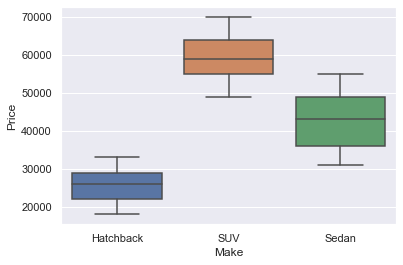

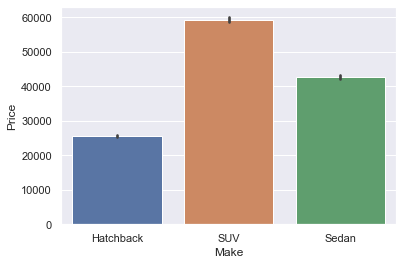

In [46]:
sns.boxplot(data=df, x='Make', y='Price');
plt.show()
sns.barplot(data=df, x='Make', y='Price');
plt.show()

In [47]:
print(df.groupby(['Make'])['Price'].mean())
print(df.groupby(['Make'])['Price'].min())
print(df.groupby(['Make'])['Price'].max())

Make
Hatchback   25561.08597
SUV         59303.79747
Sedan       42671.73913
Name: Price, dtype: float64
Make
Hatchback    18000
SUV          49000
Sedan        31000
Name: Price, dtype: int64
Make
Hatchback    33000
SUV          70000
Sedan        55000
Name: Price, dtype: int64


- **Hatchback**: Customers who purchased this type of car paid an average price of 25561. The prices for this car type range between 18000 and 33000
- **SUV**: Customers who purchased this type of car paid an average price of 59304. The prices for this car type range between 49000 and 70000
- **Sedan**: Customers who purchased this type of car paid an average price of 42672. The prices for this car type range between 31000 and 55000

#### Relationship between Number of Dependents and Make

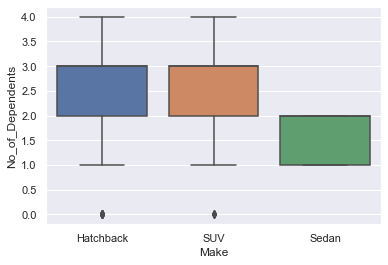

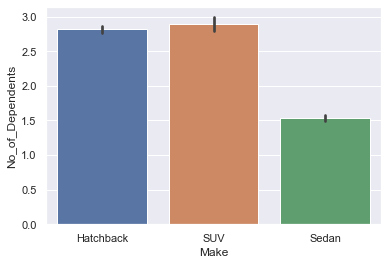

In [48]:
sns.boxplot(data=df, x='Make', y='No_of_Dependents');
plt.show()
sns.barplot(data=df, x='Make', y='No_of_Dependents');
plt.show()

In [49]:
print((df.groupby(['Make'])['No_of_Dependents'].mean()))
print(df.groupby(['Make'])['No_of_Dependents'].min())
print(df.groupby(['Make'])['No_of_Dependents'].max())

Make
Hatchback   2.82014
SUV         2.89451
Sedan       1.53696
Name: No_of_Dependents, dtype: float64
Make
Hatchback    0
SUV          0
Sedan        1
Name: No_of_Dependents, dtype: int64
Make
Hatchback    4
SUV          4
Sedan        2
Name: No_of_Dependents, dtype: int64


- **Hatchback**: Customers who purchase this type of car have an approximate average number of dependents of 3. The number of dependents of these customers are between 0 and 4
- **SUV**: Customers who purchase this type of car have an approximate average number of dependents of 3. The number dependents of these customers are between 0 and 4
- **Sedan**: Customers who purchase this type of car have an approximate average number of dependents of 2. The number of dependents of these customers are between  1 and 2

#### Relationship between Salary and Make

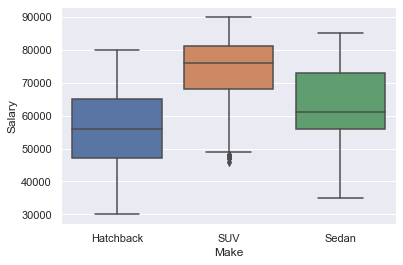

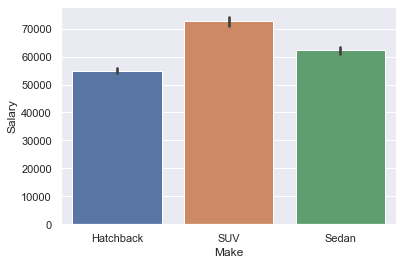

In [50]:
sns.boxplot(data=df, x='Make', y='Salary');
plt.show()
sns.barplot(data=df, x='Make', y='Salary');
plt.show()

In [51]:
print((df.groupby(['Make'])['Salary'].mean()))
print(df.groupby(['Make'])['Salary'].min())
print(df.groupby(['Make'])['Salary'].max())

Make
Hatchback   54969.45701
SUV         72683.54430
Sedan       62213.04348
Name: Salary, dtype: float64
Make
Hatchback    30000
SUV          46000
Sedan        35000
Name: Salary, dtype: int64
Make
Hatchback    80000
SUV          90000
Sedan        85000
Name: Salary, dtype: int64


- **Hatchback**: Customers who purchase this type of car earn an approximate average salary of 54970. Their salaries range from 30000 to 80000
- **SUV**: Customers who purchase this type of car earn an approximate average salary of 72684. Their salaries range from 46000 to 90000
- **Sedan**: Customers who purchase this type of car earn an approximate average salary of 62213. Their salaries range from 35000 to 85000

#### Relationship between Partner Salary and Make

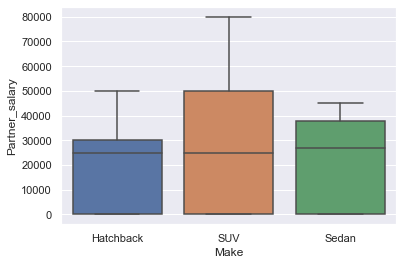

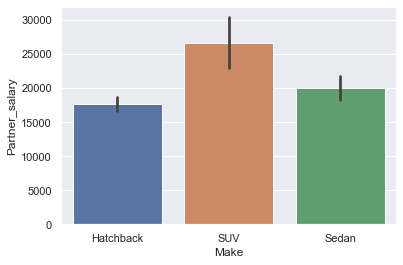

In [52]:
sns.boxplot(data=df, x='Make', y='Partner_salary');
plt.show()
sns.barplot(data=df, x='Make', y='Partner_salary');
plt.show()

In [53]:
print((df.groupby(['Make'])['Partner_salary'].mean()))
print(df.groupby(['Make'])['Partner_salary'].min())
print(df.groupby(['Make'])['Partner_salary'].max())

Make
Hatchback   17707.01357
SUV         26632.91139
Sedan       20028.26087
Name: Partner_salary, dtype: float64
Make
Hatchback    0
SUV          0
Sedan        0
Name: Partner_salary, dtype: int64
Make
Hatchback    50000
SUV          80000
Sedan        45000
Name: Partner_salary, dtype: int64


- **Hatchback**: Customers who purchase this type of car have partners earning an approximate average salary of 17707. The partners' salaries range from 0 to 50000
- **SUV**: Customers who purchase this type of car have partners earning an approximate average salary of 26633. The partners' salaries range from 0 to 80000
- **Sedan**: Customers who purchase this type of car have partners earning an approximate average salary of 20028. The partners' salaries range from 0 to 45000

#### Relationship between Total Salary and Make

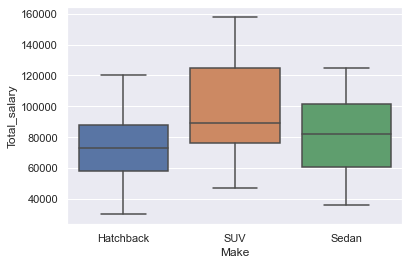

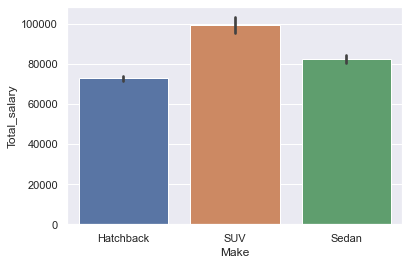

In [54]:
sns.boxplot(data=df, x='Make', y='Total_salary');
plt.show()
sns.barplot(data=df, x='Make', y='Total_salary');
plt.show()

In [55]:
print((df.groupby(['Make'])['Total_salary'].mean()))
print(df.groupby(['Make'])['Total_salary'].min())
print(df.groupby(['Make'])['Total_salary'].max())

Make
Hatchback   72676.47059
SUV         99316.45570
Sedan       82241.30435
Name: Total_salary, dtype: float64
Make
Hatchback    30000
SUV          47000
Sedan        36000
Name: Total_salary, dtype: int64
Make
Hatchback    120000
SUV          158000
Sedan        125000
Name: Total_salary, dtype: int64


- **Hatchback**: Customers who purchase this type of car earn an approximate average total salary of 72677. Their total salaries range from 30000 to 120000
- **SUV**: Customers who purchase this type of car earn an approximate average total salary of 99317. Their total salaries range from 47000 to 158000
- **Sedan**: Customers who purchase this type of car earn an approximate average total salary of 82241. Their total salaries range from 36000 to 125000

In [56]:
df[cat_cols].head(1)

,Gender,Profession,Marital_status,Education,Personal_loan,House_loan,Partner_working,Make
0,Male,Salaried,Married,Post Graduate,No,Yes,Yes,Hatchback


#### Relationship between Gender and Make

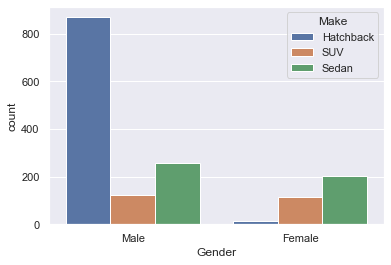

In [57]:
sns.countplot(data=df, x = 'Gender', hue='Make');

- **Male**: Male customers bought Hatchback make the most followed by Sedan then SUV
- **Female**: Female customers bought Sedan make the most, followed by SUV then Hatchback

#### Relationship between Profession and Make

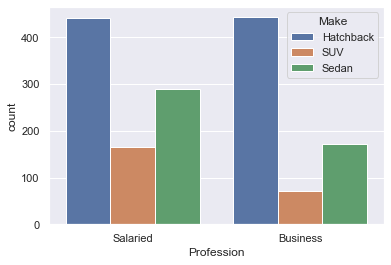

In [58]:
sns.countplot(data=df, x = 'Profession', hue='Make');

Both salaried customers and those who own a business purchased Hatchback make the most, followed by Sedan then SUV

#### Relationship between Marital Status and Make

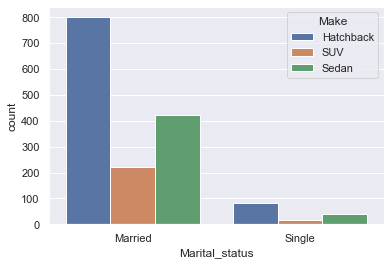

In [59]:
sns.countplot(data=df, x = 'Marital_status', hue='Make');

Married and Single customers purchased Hatchback make the most, followed by Sedan then SUV

#### Relationship between Education and Make

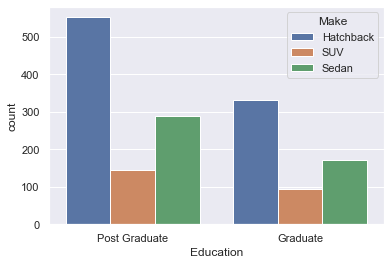

In [60]:
sns.countplot(data=df, x = 'Education', hue='Make');

The education categories of customers purchased Hatchback make the most, followed by Sedan then SUV

#### Relationship between Personal Loan and Make

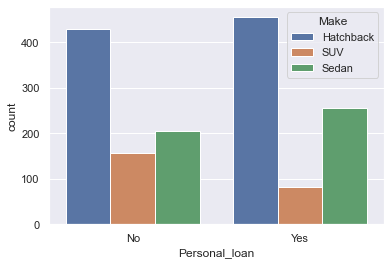

In [61]:
sns.countplot(data=df, x = 'Personal_loan', hue='Make');

In terms of personal loan, the two categories of customers purchased Hatchback make the most, followed by Sedan then SUV

#### Relationship between House Loan and Make

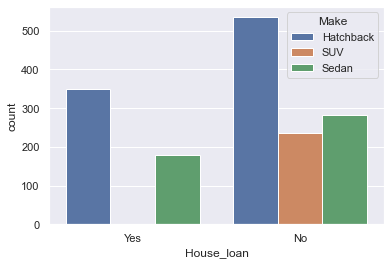

In [62]:
sns.countplot(data=df, x = 'House_loan', hue='Make');

- **Yes**: Customers who availed themselves of house loan bought Hatchback make the most, followed by Sedan. None of them purchased a SUV
- **No**: All customers who did not avail themselves of house loan bought Hatchback make the most, followed by Sedan then SUV

#### Relationship between Partner Working and Make

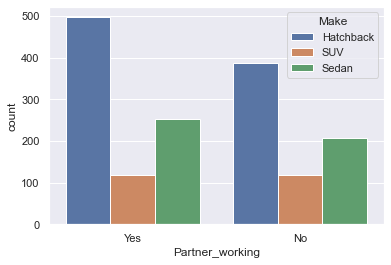

In [63]:
sns.countplot(data=df, x = 'Partner_working', hue='Make');

Customers with working partners and those without purchased Hatchback make the most, followed by Sedan then SUV

## Multivariate Analysis

In [64]:
df.head(1)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback


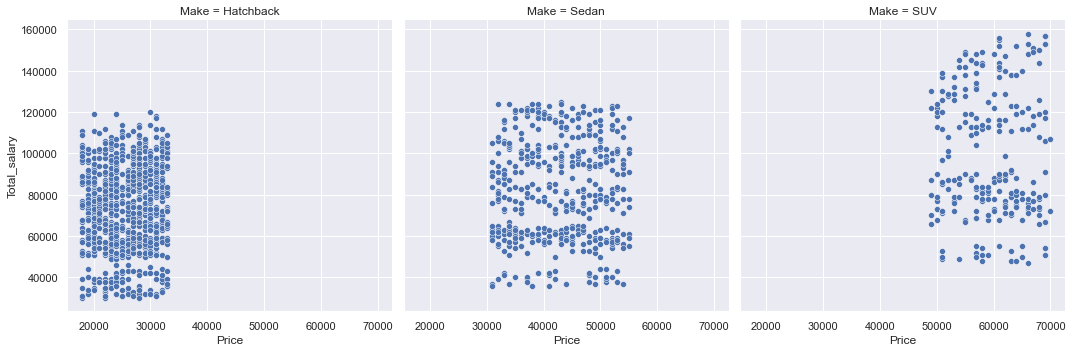

In [65]:
sns.relplot(data=df, x='Price', y='Total_salary', col='Make', col_order=['Hatchback', 'Sedan', 'SUV']) ;

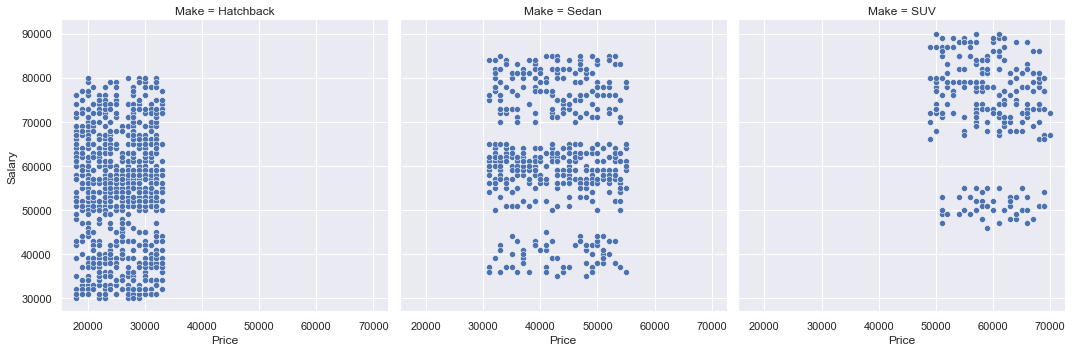

In [66]:
sns.relplot(data=df, x='Price', y='Salary', col='Make', col_order=['Hatchback', 'Sedan', 'SUV']);

- As seen in earlier plots as Price increases generally, so do Salary and Total Salary
- However, more importantly here, we see that the lowest priced car make is Hatchback, followed by Sedan which is the penultimate highest priced, then SUV which is the highest priced; and as the prices of each car make rises we see an attendant rise in Salary and Total Salary.
- This seems to align with our earlier intuition that as customers age, they rise in their jobs or businessess and thus, earn more, and are then able to purchase a higher-priced car make. Let's investigate this further

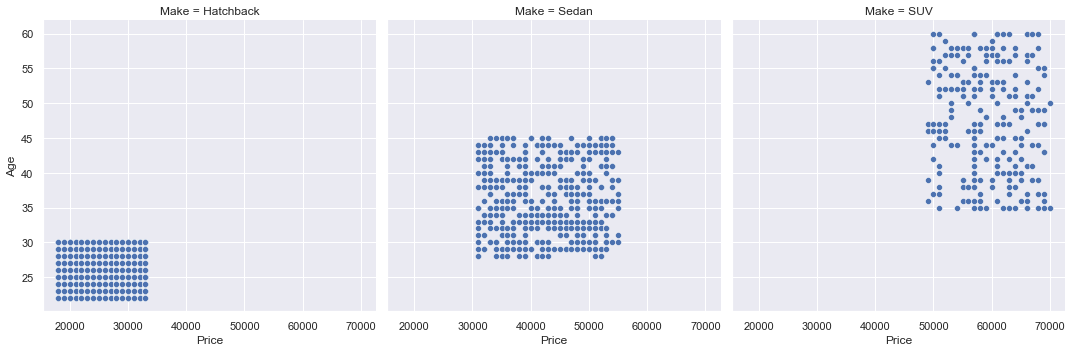

In [67]:
sns.relplot(data=df, x='Price', y='Age', col='Make', col_order=['Hatchback', 'Sedan', 'SUV']);

- We see that as the age of each customer increases, so does the price of car they purchase and these rises follow the order of Hatchback, Sedan and SUV
- Let's investigate further

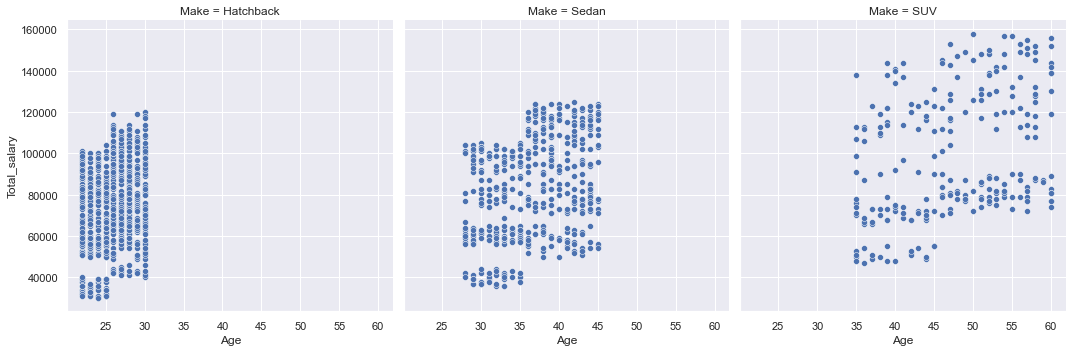

In [68]:
sns.relplot(data=df, x='Age', y='Total_salary', col='Make', col_order=['Hatchback', 'Sedan', 'SUV']);

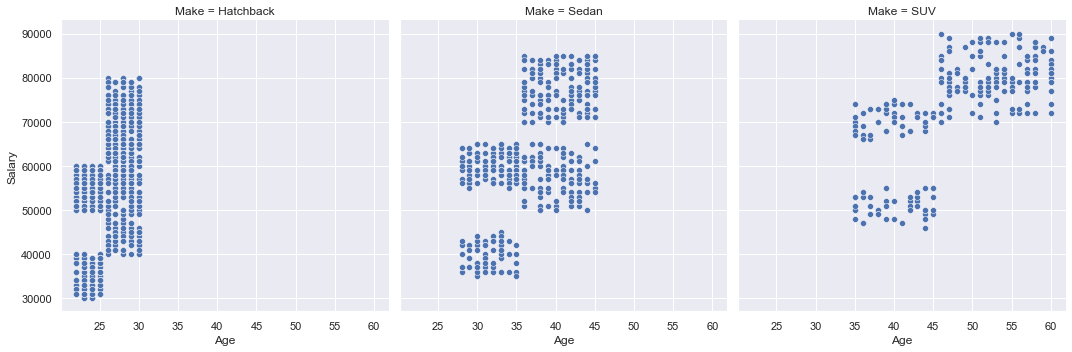

In [69]:
sns.relplot(data=df, x='Age', y='Salary', col='Make', col_order=['Hatchback', 'Sedan', 'SUV']);

- We get very similar insights in Age versus Salary/Total Salary and Make as we did in Price versus Salary/Total Salary and Make, as well as in Price versus Age and Make
- As the age of each customer rises, we again see an attendant rise in Salary and Total Salary and these rises follow the earlier patterns seen with regards to the car makes
- At this point, we can say that our intuition was spot on

Finally, let's see the percentage of customers who bought each car make

In [70]:
df.loc[(df['Make']=='Hatchback') & (df['Age']<=30)].shape[0]/df.shape[0]*100

55.91397849462365

In [71]:
df.loc[(df['Make']=='Sedan') & (df['Age']>=28) & (df['Age']<=45)].shape[0]/df.shape[0]*100

29.095509171410498

In [72]:
df.loc[(df['Make']=='SUV') & (df['Age']>=35)].shape[0]/df.shape[0]*100

14.990512333965844

56% of all customers bought Hatchbacks, about 29% bought Sedans and 15% bought SUVs


In [73]:
df.loc[(df['Make']=='SUV') & (df['Age']>45)].shape[0]

141

In [74]:
df.loc[(df['Make']=='SUV') & (df['Age']<45)].shape[0]

88

In [75]:
#df.loc[(df['Make']=='Sedan') & (df['Age']>=4)].shape[0]

## Actionable Insights and Recommendations

### Insights

We analysed a dataset of nearly 1600 car buyers in the US and their attendant numerous information. The data included both male and female customers between the ages of 22 and 60 who, alongside other features, were either married or single and all of whom were working class. The data also included the salary of each customer and their partners, the type of car they bought and the respective price. The main variable of interest here is the make of car purchased. Each car purchaser bought one of three car makes; Hatchback, Sedan or SUV.

We wanted to identify the demand trend for these 3 car makes and the customer profile of their buyers, thus, we arrived at the following conclusions:

- The most purchased car make by customers is Hatchback
- The least purchased car make by customers is SUV
- SUV is the most priced at an average of 59304, followed by Sedan at 42672 and then Hatchback at 25561
- We can conclude that the older a customer is, the higher they earn and thus, the higher their purchasing power
- The oldest customers who were also the customers with the highest salaries bought SUV
- The customers with the middle ages who were also the customers with the mid-sized salaries bought Sedan
- The youngest customers who were also the customers with the least salaries opted for Hatchback
- 75% of all customers are between the ages of 22 and 38

**Hatchback**:
- Averagely priced at  25561. Costs between 18000 and 33000
- Purchased by customers between the ages of 22 and 30
- Purchased by customers having 3 dependents on average or between 0 to 4
- Purchased by customers with an average salary of 54970, and earning between 30000 to 80000
- Purchased by customers having partners with an average salary of 17707, and earning between 0 to 50000
- Purchased by customers with an average total salary of 72677, and earning between 30000 to 120000
- Most purchased by male customers
- Least purchased by female customers
- Purchased in equal amounts by customers who earn salaries and those who own businesses

**Sedan**:
- Averagely priced at 42672. Costs between 31000 and 55000 
- Purchased by customers between the ages of 28 and 45
- Purchased by customers having 2 dependents on average or between 1 to 2
- Purchased by customers with an average salary of 62213, and earning between 35000 to 85000
- Purchased by customers having partners with an average salary of 20028, and earning between 0 to 45000
- Purchased by customers with an average total salary of 82241, and earning between 36000 to 125000
- Least purchased by male customers
- Most purchased by female customers
- 
 
**SUV**:
- Averagely priced at  59304. Costs between 49000 and 70000
- Purchased by customers between the ages of 35 and 60
- Purchased by customers having 3 dependents on average or between 0 to 4
- Purchased by customers with an average salary of 72684, and earning between 46000 to 90000
- Purchased by customers having partners with an average salary of 26633, and earning between 0 to 80000
- Purchased by customers with an average total salary of 99317, and earning between 47000 to 158000
- Not purchased by customers who took house loan
- Purchased more by customers who did not take personal loan compared to those who did
- Purchased in equal amounts by customers whose partners work and those who do not




### Recommendations

- Austo should prioritise customers aged between 22 and 45. This group of customers constitute the largest portion (more than 75%) of US car buyers
- The group of customers mentioned above and who also constitute 85% of all customers purchased Hatchback and Sedan make cars, hence, Austo should ensure availability of these two cars always
- While SUV was purchased mainly by the group of customers (older customers, especially those above 45) who are in the minority, they will always be there, and very importantly, they pay the most for each unit of car purchased (since SUV is the most expensive make). Hence, Austo should ensure the availability of this make of car for this group of of customers, how ever small; the cummulative effect of each purchase by them will surely be significant.
- Since of the Hatchback and Sedan buyers, the males preferred Hatchback while the the females preferred Sedan, Austo should craft their marketing and advert efforts accordingly
- SUV is mostly purchased by customers who without house and personal loans. Austo should craft their marketing and advert efforts accordingly